In [1]:
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.12.0+cpu
GPU available: False
Device: cpu
Using device: cpu


In [5]:
# Tensors
t1 = torch.tensor([1.0, 2.0, 3.0])
t2 = torch.zeros(3, 4)
t3 = torch.ones(2, 3)
t4 = torch.randn(3, 3)
t5 = torch.arange(0, 10, 2)

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)

# Converting fron numpy
arr = np.array([1.0, 2.0, 3.0])
t_from_np = torch.from_numpy(arr)
print(t_from_np)

# Convert to numpy
back_to_np = t1.numpy()
print(back_to_np)

tensor([1., 2., 3.])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[-1.1004, -0.6242, -0.0087],
        [ 0.8628, -0.1060, -0.5457],
        [-0.4979, -0.8412, -1.5794]])
tensor([0, 2, 4, 6, 8])
tensor([1., 2., 3.], dtype=torch.float64)
[1. 2. 3.]


In [7]:
# Tensor operations
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print(a + b)
print(a * b)
print(a @ b)
print(a.T)
print(a.sum())
print(a.mean(dim = 0))
print(a.reshape(1, 4))
print(a.shape)

tensor([[ 6.,  8.],
        [10., 12.]])
tensor([[ 5., 12.],
        [21., 32.]])
tensor([[19., 22.],
        [43., 50.]])
tensor([[1., 3.],
        [2., 4.]])
tensor(10.)
tensor([2., 3.])
tensor([[1., 2., 3., 4.]])
torch.Size([2, 2])


In [8]:
# Autograd

# requires_grad = True tells Pytorch to track operations on the tensor
x = torch.tensor(3.0, requires_grad = True)

# Define a simple function
y = x**2 + 2*x + 1
print(f"y = {y}")

# Compute gradient dy/dx
y.backward()
print(f"dy/dx at x = 3: {x.grad}")

y = 16.0
dy/dx at x = 3: 8.0


In [10]:
# More practice

# Simulate a simple linear model: output = weight * input + bias
weight = torch.tensor(2.0, requires_grad = True)
bias = torch.tensor(1.0, requires_grad = True)

# Input and target
x = torch.tensor(5.0)
target = torch.tensor(12.0)

# Forward pass
output = weight * x + bias
print(f"Output: {output}")

# Loss (MSE)
loss = (output - target)**2
print(f"Loss: {loss}")

# Backwards pass, compute gradients
loss.backward()
print(f"d(loss)/d(weight): {weight.grad}")
print(f"d(loss)/d(bias): {bias.grad}")

# Hand calculations to confirm
# output = 2 * 5 + 1 = 11
# loss = (11 - 12) ^ 2 = 1
# d(loss)/d(weight) = 2(output - target) * x = 2 * (-1) * 5 = -10 (since we take partial derivative of output, chain rule)
# d(loss) / d(bias) = 2 * (output - target) * 1 = 2 * (-1) = -2

Output: 11.0
Loss: 1.0
d(loss)/d(weight): -10.0
d(loss)/d(bias): -2.0


In [12]:
# Gradient descent by hand

# Simple linear reg from scratch
torch.manual_seed(42)

# True relationship: y = 3x + 2
X = torch.randn(100, 1)
y = 3 * X + 2 + torch.randn(100, 1) * 0.1 # Add some small noise

# Initialize weights randomly
weight = torch.randn(1, requires_grad = True)
bias = torch.randn(1, requires_grad = True)

learning_rate = 0.1
losses = []

for epoch in range(100):
    # Forward pass
    y_pred = weight * X + bias

    # Loss (MSE)
    loss = ((y_pred - y)**2).mean()
    losses.append(loss.item())

    # Backward pass
    loss.backward()

    # Update weights (gradient descent)
    with torch.no_grad(): # dont autograd track these operations
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad

    # Zero gradients
    weight.grad.zero_()
    bias.grad.zero_()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}, "
              f"weight = {weight.item():.3f}, bias = {bias.item():.3f}")

print(f"\nFinal: weight = {weight.item():.3f} (true: 3.0), bias = {bias.item():.3f} (true 2.0)")

Epoch 0: loss = 12.1962, weight = 0.924, bias = 0.260
Epoch 10: loss = 0.1235, weight = 2.786, bias = 1.849
Epoch 20: loss = 0.0089, weight = 2.978, bias = 1.990
Epoch 30: loss = 0.0078, weight = 2.999, bias = 2.003
Epoch 40: loss = 0.0078, weight = 3.001, bias = 2.003
Epoch 50: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 60: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 70: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 80: loss = 0.0078, weight = 3.001, bias = 2.004
Epoch 90: loss = 0.0078, weight = 3.001, bias = 2.004

Final: weight = 3.001 (true: 3.0), bias = 2.004 (true 2.0)


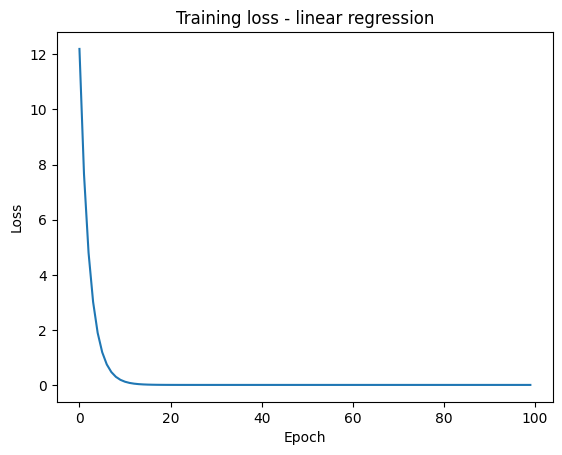

In [13]:
# Plot the loss curve
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss - linear regression')
plt.show()

## Day 1 Key Concepts

**Tensor**: PyTorch's array - like numpy but GPU-compatible and differentiable

**requires_grad**: tells PyTorch to track operations for gradient computation

**Forward pass** computing output from input through the model

**Loss**: a number measuring how wrong the model's predictions are (lower = better)

**Backward pass (.backward())**: automatically computes gradients of loss with respect to all tracked tensors

**Gradient descent**: nudge weights in the direction that reduces loss, scaled by learning_rate

**grad.zero_()**: must zero gradients each step - PyTorch accumulates gradients by default

**torch.no_grad()**: used when updating weights - don't want PyTorch tracking this update step